# 04 - Baseline supervised models

Train classifiers on **handcrafted features only** to answer: **how much signal exists in simple biological sequence features before we bring in ESM embeddings?** 

Setup:
- Drop duplicate sequences (keep first) to prevent train/test leakage.
- Stratified train/test split (80/20), held-out test never used for tuning.
- 5-fold stratified CV **on the training set** for a stable model-selection signal.
- Models: Logistic Regression, Random Forest, XGBoost, HistGB.
- Headline metric: **macro-F1** (classes are mildly imbalanced).

All model + pipeline logic lives in `src/train.py` so it's reusable for hybrid model. Each model is an sklearn `Pipeline`, so preprocessing (scaling for LogReg) travels with the model and can't leak across the split.

## 1. Setup & load features

In [1]:
!pip install xgboost

In [2]:
from xgboost import XGBClassifier

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

import train as T
import features as F

CLASS_ORDER = ["enzyme", "dna_rna_binding", "receptor", "transporter", "structural", "other"]

In [4]:
feats = pd.read_csv(PROCESSED_DIR / "sequence_features.csv", index_col="accession")

FEATURE_COLS = F.feature_columns()
print(f"Samples (raw): {len(feats)}   Features: {len(FEATURE_COLS)}")
feats.head()

Samples (raw): 8520   Features: 32


,function_class,seq_length,molecular_weight,aromaticity,instability_index,isoelectric_point,gravy,frac_hydrophobic,frac_polar_uncharged,frac_positive,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
accession,,,,,,,,,,,,,,,,,,,,,
A0A1B0GTW7,enzyme,788,85395.9714,0.065990,41.752284,8.038192,-0.141624,0.380711,0.393401,0.121827,...,0.016497,0.017766,0.077411,0.050761,0.050761,0.096447,0.060914,0.053299,0.016497,0.025381
A0JP26,other,581,65709.6952,0.041308,48.240448,6.239750,-0.775387,0.333907,0.314974,0.177281,...,0.030981,0.060241,0.027539,0.051635,0.049914,0.080895,0.037866,0.046472,0.008606,0.017212
A0PK11,transporter,232,25445.8398,0.112069,31.439655,6.508372,0.757759,0.556034,0.254310,0.090517,...,0.017241,0.025862,0.030172,0.038793,0.025862,0.056034,0.030172,0.107759,0.021552,0.025862
A1A4S6,structural,786,89373.5585,0.083969,50.047226,6.751472,-0.585623,0.346056,0.334606,0.160305,...,0.022901,0.044529,0.063613,0.043257,0.055980,0.080153,0.053435,0.052163,0.008906,0.021628
A1A519,dna_rna_binding,330,37157.5659,0.045455,74.251212,4.997989,-1.018485,0.260606,0.400000,0.145455,...,0.033333,0.027273,0.054545,0.063636,0.063636,0.121212,0.066667,0.066667,0.012121,0.015152


## 2. Drop duplicate sequences (leakage control)

The EDA flagged identical sequences in the dataset. If the same sequence lands in
both train and test, the model can memorise it and the test score is inflated. We
keep the **first** occurrence of each unique sequence and drop the rest.

The feature table is indexed by `accession` and doesn't carry the raw sequence, so
we look up duplicates from the source labeled dataset and filter `feats` to the
accessions we keep. 

In [5]:
src_df = pd.read_csv(PROCESSED_DIR / "labeled_dataset.csv")

dup_groups = src_df[src_df["sequence"].duplicated(keep=False)]

# Accessions to keep: first occurrence of each unique sequence.
keep_acc = src_df.drop_duplicates(subset="sequence", keep="first")["accession"]

before = len(feats)
feats = feats.loc[feats.index.intersection(keep_acc)]
print(f"\nDropped {before - len(feats)} duplicate-sequence rows "
      f"({before} -> {len(feats)} unique sequences).")


Dropped 7 duplicate-sequence rows (8520 -> 8513 unique sequences).


In [6]:
X = feats[FEATURE_COLS]
y = feats["function_class"]

print("Class balance after dedup:")
print(y.value_counts().reindex(CLASS_ORDER).to_string())

Class balance after dedup:
function_class
enzyme             2683
dna_rna_binding    1723
receptor            758
transporter        1298
structural          748
other              1303


## 3. Stratified train/test split

Stratify on the label so every class keeps its proportion in both folds. The test
set is set aside now and only touched in section 5.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=T.RANDOM_STATE
)
print(f"Train: {len(X_train)}   Test: {len(X_test)}")
print("Train class balance (%):")
print((y_train.value_counts(normalize=True).reindex(CLASS_ORDER) * 100).round(1).to_string())

Train: 6810   Test: 1703
Train class balance (%):
function_class
enzyme             31.5
dna_rna_binding    20.2
receptor            8.9
transporter        15.2
structural          8.8
other              15.3


## 4. Train baselines (CV on train + fit)

`run_baselines` does, for each model: 5-fold stratified CV macro-F1 on the train
set, then fits on the full train set ready for test evaluation. LogReg is scaled
inside its pipeline; RF and XGBoost pass features through unscaled.

In [8]:
metrics_df, fitted, evals = T.run_baselines(
    X_train, y_train, X_test, y_test,
    feature_cols=FEATURE_COLS,
    class_names=CLASS_ORDER,
    n_splits=5,
)
metrics_df

,model,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_macro_f1,test_weighted_f1
2,xgboost,0.4803,0.0146,0.5649,0.5267,0.5541
3,histgb,0.4759,0.0115,0.5567,0.5247,0.5488
1,random_forest,0.4596,0.0056,0.5555,0.5091,0.5350
0,logreg,0.3988,0.0158,0.4427,0.4197,0.4487


The CV and test macro-F1 columns should be close — a large gap would flag
overfitting. Pick the headline model by **test macro-F1**.

## 5. Detailed report for the best model

Per-class precision/recall on the held-out test set. This is where we see *which*
classes the handcrafted features can and can't separate.

In [9]:
best_name = metrics_df.iloc[0]["model"]
print(f"Best model: {best_name}\n")

from sklearn.metrics import classification_report
y_pred_best = evals[best_name]["y_pred"]
print(classification_report(y_test, y_pred_best, target_names=CLASS_ORDER, zero_division=0))

Best model: xgboost

                 precision    recall  f1-score   support

         enzyme       0.55      0.61      0.58       345
dna_rna_binding       0.58      0.78      0.67       537
       receptor       0.40      0.35      0.38       261
    transporter       0.67      0.51      0.58       151
     structural       0.64      0.34      0.45       149
          other       0.62      0.43      0.51       260

       accuracy                           0.56      1703
      macro avg       0.58      0.50      0.53      1703
   weighted avg       0.57      0.56      0.55      1703



## 6. Confusion matrix

Row-normalised so each row shows where a true class's proteins actually land.
Off-diagonal mass tells the biological story (e.g. receptors confused with
transporters would both be membrane-associated).

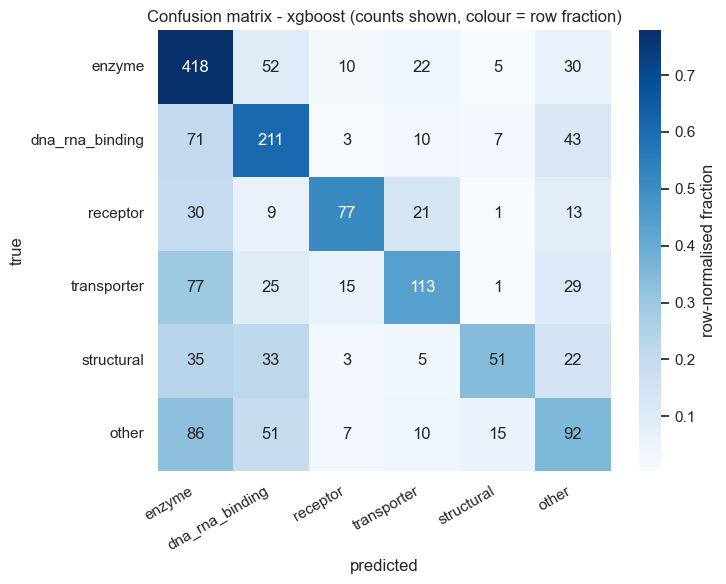

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best, labels=CLASS_ORDER)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
            cbar_kws={"label": "row-normalised fraction"}, ax=ax)
ax.set_title(f"Confusion matrix - {best_name} (counts shown, colour = row fraction)")
ax.set_xlabel("predicted")
ax.set_ylabel("true")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_baseline.png", dpi=150)
# Also save at the path the project plan names directly.
plt.savefig(RESULTS_DIR / "confusion_matrix_baseline.png", dpi=150)
plt.show()

## 7. Model comparison plot

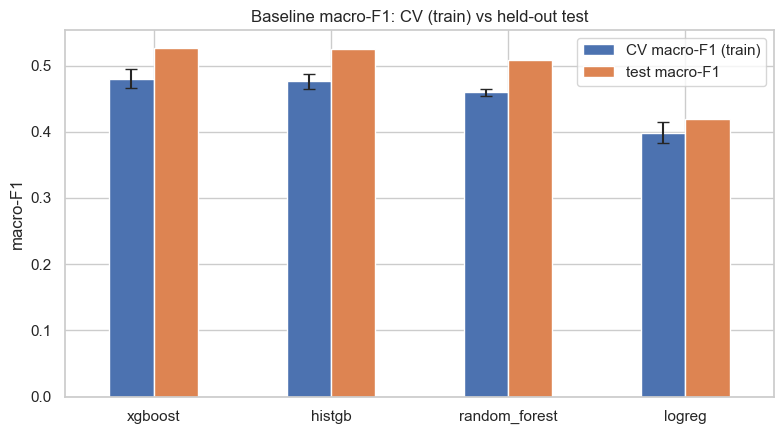

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
m = metrics_df.set_index("model")[["cv_macro_f1_mean", "test_macro_f1"]]
m.plot(kind="bar", ax=ax,
       yerr={"cv_macro_f1_mean": metrics_df.set_index("model")["cv_macro_f1_std"]},
       capsize=4)
ax.set_title("Baseline macro-F1: CV (train) vs held-out test")
ax.set_ylabel("macro-F1")
ax.set_xlabel("")
ax.legend(["CV macro-F1 (train)", "test macro-F1"])
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_macro_f1.png", dpi=150)
plt.show()

## 8. Save metrics

In [12]:
out_path = RESULTS_DIR / "baseline_metrics.csv"
metrics_df.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")
metrics_df

Saved -> C:\Users\sridi\Documents\Learning\protein-function-active-learning\results\baseline_metrics.csv


,model,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_macro_f1,test_weighted_f1
2,xgboost,0.4803,0.0146,0.5649,0.5267,0.5541
3,histgb,0.4759,0.0115,0.5567,0.5247,0.5488
1,random_forest,0.4596,0.0056,0.5555,0.5091,0.5350
0,logreg,0.3988,0.0158,0.4427,0.4197,0.4487


## 9. Interpretation

**XGBoost is the best baseline at test macro-F1 0.527** (accuracy 0.565),
just ahead of HistGB (0.525) and Random Forest (0.509), and well above Logistic
Regression (0.420). On a 6-class problem (chance ≈ 0.17), ~0.53 means simple sequence
biochemistry carries real but partial signal.

**Linear vs non-linear.** The ~0.10 gap between LogReg (0.42) and the three tree models
(0.51–0.53) is the key comparison: the class structure in these 32 features is largely
non-linear, so models that capture feature interactions win clearly.

**Feature ceiling.** XGBoost and HistGB agree to within 0.002, and HistGB's balanced class
weights didn't lift the minority classes. Two boosting models landing in the same place
indicates the ceiling is in the feature representation, not the classifier — the central
argument for moving to ESM.

**Overfitting.** CV→test gaps are small and stable (XGBoost 0.480→0.527, HistGB 0.476→0.525).
No concern on 32 features.

**Per-class (XGBoost).**
- *dna_rna_binding* — easiest (recall 0.78, F1 0.67); largest class and a distinctive
  charged-residue signature, consistent with the EDA.
- *enzyme* — solid (F1 0.58); large and biochemically coherent.
- *transporter* — mid (F1 0.58, precision 0.67); hydrophobicity aids precision but recall
  suffers as 77 transporters are read as enzyme.
- *structural* — high precision (0.64), poor recall (0.34); confident when it fires but
  misses two-thirds.
- *receptor* — weakest (F1 0.38); functionally heterogeneous and bleeds into enzyme and
  transporter (shared membrane-association).
- *other* — mediocre (F1 0.51) and diffuse, as expected for a catch-all with no signature.

**Dominant confusion.** Everything leaks into *enzyme* (86 other, 77 transporter,
71 dna_rna_binding) — partly the largest-class pull, partly that catalytic proteins span
broad sequence space, making "enzyme" a soft default. A known failure mode ESM should help.